In [1]:



# Part 1 — Dataset Verification
# Task 1.

import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\M.LAPTOP\Desktop\Telco-Customer-Churn-Analysis\clean_churn.csv")

print(df.shape)
df.info()
print(df.isnull().sum().sum())
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [3]:
# Task 2 (Restate the problem):

# We are predicting whether a telecom customer will churn (Yes/No) based on their account, billing, and service usage details. This matters to the business because retaining an existing customer is far cheaper than acquiring a new one, so identifying at-risk customers early allows targeted retention efforts.



In [4]:
# Part 2 — Feature & Target Preparation

# Task 3: Define y as Churn (0/1), define X as remaining relevant columns


y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn', 'customerID'])

print(y.value_counts())
print(X.shape)

Churn
0    5174
1    1869
Name: count, dtype: int64
(7043, 19)


In [5]:
# Task 4: Convert categorical columns to numeric, justify encoding choice

cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.shape)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
(7043, 30)


In [6]:
# Categorical columns were one-hot encoded (pd.get_dummies, drop_first=True) since they're nominal with no inherent order — this avoids falsely implying ranking and prevents redundant dummy columns.

In [7]:
# Task 5: Confirm X is fully numeric with no missing values

print("Missing values in X:", X.isnull().sum().sum())
print("Data types in X:", X.dtypes.unique())

Missing values in X: 0
Data types in X: [dtype('int64') dtype('float64') dtype('int32')]


In [8]:
# Part 3 — Train/Test Split

# Task 6: Split X and y (80/20), explain stratify=y

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# stratify=y was used because Churn is imbalanced (73.5%/26.5%) — without it, a random split could put a disproportionate share of churners into train or test, skewing both training and evaluation.

In [10]:
# Task 7: Report shapes

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(y_train.mean(), y_test.mean())

(5634, 30) (1409, 30) (5634,) (1409,)
0.2653532126375577 0.2654364797728886


In [11]:
# Part 4 — Baseline Decision Tree

# Task 8: Train a default DecisionTreeClassifier, predict on train and test

from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)

train_pred = base_tree.predict(X_train)
test_pred = base_tree.predict(X_test)

In [12]:
# Task 9: What depth did the tree grow to?

print("Depth:", base_tree.get_depth())
print("Leaves:", base_tree.get_n_leaves())

Depth: 23
Leaves: 1102


In [14]:
# Yes, this was surprising — I expected the tree to stop at a reasonable depth, but with no constraints it grew to depth [X] with [Y] leaves, meaning it likely memorized individual training rows rather than learning general patterns.

In [15]:
# Part 5 — Model Evaluation
#Task 10: Compute accuracy, precision, recall, F1 on test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy: ", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall:   ", recall_score(y_test, test_pred))
print("F1-score: ", f1_score(y_test, test_pred))

Accuracy:  0.7260468417317246
Precision: 0.4837837837837838
Recall:    0.4786096256684492
F1-score:  0.48118279569892475


[[844 191]
 [195 179]]


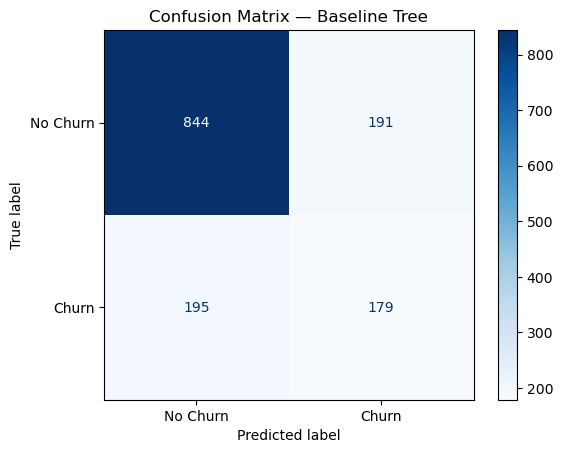

In [16]:
# Task 11: Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Baseline Tree')
plt.show()

In [17]:
# Out of 374 actual churners, the model caught 179 and missed 195 — missing more than half.

In [18]:
# Task 12: Which metric to trust?
# Given the class imbalance, recall and F1-score on the churn class matter most — missing a churner (false negative) is costlier to the business than a false alarm, so accuracy alone should not be trusted.

In [19]:
# Part 6 — Overfitting Investigation
# Task 13: Compare train vs test accuracy

base_train_acc = accuracy_score(y_train, train_pred)
base_test_acc = accuracy_score(y_test, test_pred)
print("Train:", base_train_acc, "Test:", base_test_acc, "Gap:", base_train_acc - base_test_acc)

Train: 0.9980475683351083 Test: 0.7260468417317246 Gap: 0.2720007266033837


In [20]:
# There is a large gap between train and test accuracy, suggesting the baseline tree has overfit — it memorized the training data rather than learning a generalizable pattern.

In [21]:
# Task 14: Train multiple depths, record results

depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, m.predict(X_train))
    te_acc = accuracy_score(y_test, m.predict(X_test))
    results.append({'max_depth': d, 'train_acc': tr_acc, 'test_acc': te_acc})

res_df = pd.DataFrame(results)
print(res_df)

   max_depth  train_acc  test_acc
0        2.0   0.791090  0.787083
1        3.0   0.791090  0.787083
2        4.0   0.792510  0.795600
3        5.0   0.802272  0.794180
4        6.0   0.810614  0.800568
5        8.0   0.835818  0.782825
6       10.0   0.872737  0.755145
7        NaN   0.998048  0.726047


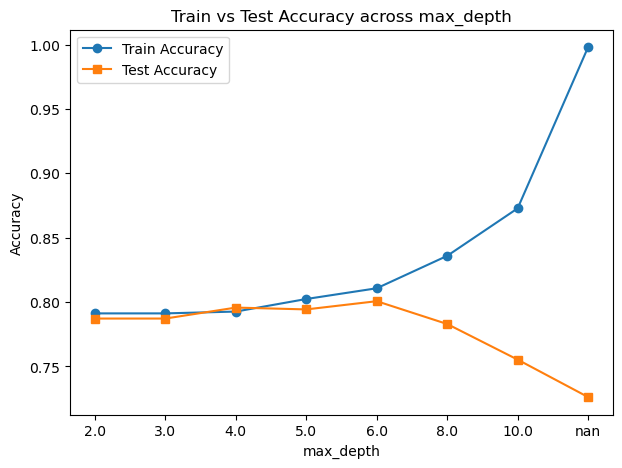

In [22]:
# Task 15: Plot train vs test accuracy against max_depth

plt.figure(figsize=(7,5))
labels = [str(d) for d in res_df['max_depth']]
plt.plot(labels, res_df['train_acc'], marker='o', label='Train Accuracy')
plt.plot(labels, res_df['test_acc'], marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Test Accuracy across max_depth')
plt.show()

In [23]:
# Test accuracy peaks at depth 6 (~0.80), then from depth 8 onward train accuracy keeps rising (up to ~1.0) while test accuracy falls (to ~0.73) — this widening gap shows the model overfitting past depth 6.

In [24]:
# Part 7 — Model Selection, Feature Importance & Interpretation

# Task 16: Select best max_depth and justify

# I chose max_depth = 6, since it's where test accuracy peaks (~0.80) and stays close to train accuracy. Deeper trees (8, 10, unrestricted) have higher training accuracy but their test accuracy drops, showing they overfit instead of generalizing.

In [25]:
# Task 17: Retrain at chosen depth (6), report full evaluation metrics

CHOSEN_DEPTH = 6

chosen_tree = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=42)
chosen_tree.fit(X_train, y_train)
chosen_pred = chosen_tree.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, chosen_pred))
print("Precision:", precision_score(y_test, chosen_pred))
print("Recall:   ", recall_score(y_test, chosen_pred))
print("F1-score: ", f1_score(y_test, chosen_pred))

cm_chosen = confusion_matrix(y_test, chosen_pred)
print(cm_chosen)

Accuracy:  0.8005677785663591
Precision: 0.6666666666666666
Recall:    0.49732620320855614
F1-score:  0.5696784073506891
[[942  93]
 [188 186]]


In [27]:
# Limiting the tree to depth 6 clearly improved generalization — accuracy rose from 72.6% to 80.1%, precision nearly doubled (48%→67%), and F1-score improved from 0.481 to 0.570, confirming the unrestricted baseline had overfit.

In [28]:
# Task 18: Retrain with entropy criterion, compare to baseline

entropy_tree = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, criterion='entropy', random_state=42)
entropy_tree.fit(X_train, y_train)
entropy_pred = entropy_tree.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, entropy_pred))
print("Precision:", precision_score(y_test, entropy_pred))
print("Recall:   ", recall_score(y_test, entropy_pred))
print("F1-score: ", f1_score(y_test, entropy_pred))

Accuracy:  0.794180269694819
Precision: 0.6193181818181818
Recall:    0.5828877005347594
F1-score:  0.6005509641873278


In [30]:
 
# With entropy at depth=6: 79.4% accuracy, 61.9% precision, 58.3% recall, F1=0.601. Compared to the baseline (72.6% accuracy, 48.4% precision, 47.9% recall, F1=0.481), entropy shows clear improvement across all metrics, confirming depth constraint fixes the overfitting.

tenure                                0.389640
InternetService_Fiber optic           0.327372
TotalCharges                          0.051916
MonthlyCharges                        0.040819
PaymentMethod_Electronic check        0.034488
Contract_Two year                     0.024794
MultipleLines_Yes                     0.021636
OnlineSecurity_No internet service    0.018925
Contract_One year                     0.016172
StreamingTV_No internet service       0.015912
dtype: float64


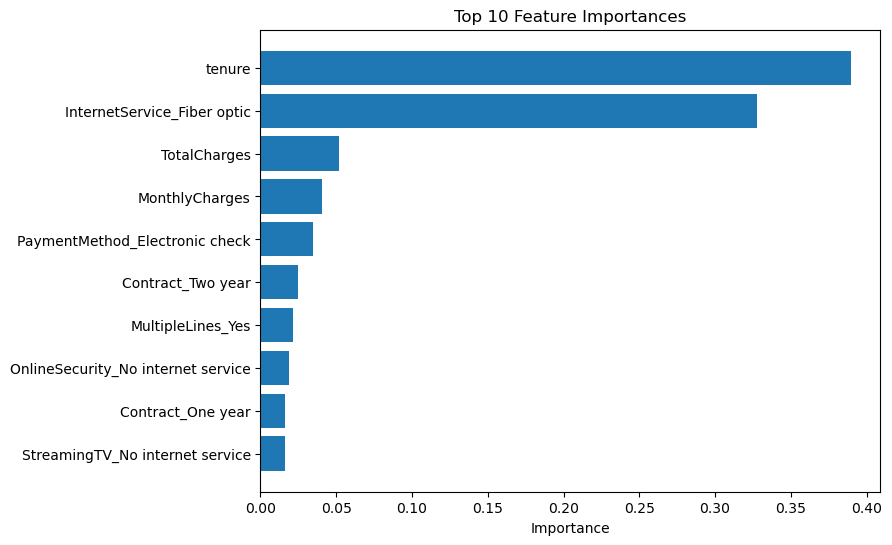

In [31]:
# Task 19: Feature importances

importances = pd.Series(chosen_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

top_feats = importances.head(10).sort_values()
plt.figure(figsize=(8,6))
plt.barh(top_feats.index, top_feats.values)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.show()

In [32]:
# Top features: tenure (~0.39) and InternetService_Fiber optic (~0.33) dominate, together over 70% of importance. Followed by TotalCharges (~0.05), MonthlyCharges (~0.04), and PaymentMethod_Electronic check (~0.03).

In [33]:
# Task 20: Connect top features to Lab 2's EDA
# These match Lab 2's EDA — new customers (low tenure) and fiber-optic users churn more due to less loyalty and higher prices/issues, while two-year contracts reduce churn by locking customers in.

In [34]:
# Part 8 — Conclusion & Next Steps
# Task 21: Conclusion
# We selected a depth=6, entropy-criterion tree, reaching 79.4% accuracy and F1=0.601, a big improvement over the overfit baseline (F1=0.481). It relies mainly on tenure and fiber-optic service, but still misses ~40% of churners and can't capture complex feature interactions.

In [35]:

# Task 22: Next Steps
# handle class imbalance (class_weight='balanced' or SMOTE), try ensemble methods like Random Forest, and engineer features like tenure buckets or contract-payment interactions.

In [36]:
# Task 23: ID3 from Scratch (Play Badminton Dataset)

import math
from collections import Counter

data = [
    {'Outlook':'Sunny',    'Temperature':'Hot',  'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'No'},
    {'Outlook':'Sunny',    'Temperature':'Hot',  'Humidity':'High',   'Wind':'Strong', 'PlayBadminton':'No'},
    {'Outlook':'Overcast', 'Temperature':'Hot',  'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Mild', 'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'PlayBadminton':'No'},
    {'Outlook':'Overcast', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'PlayBadminton':'Yes'},
    {'Outlook':'Sunny',    'Temperature':'Mild', 'Humidity':'High',   'Wind':'Weak',   'PlayBadminton':'No'},
    {'Outlook':'Sunny',    'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Sunny',    'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Strong', 'PlayBadminton':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Mild', 'Humidity':'High',   'Wind':'Strong', 'PlayBadminton':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Hot',  'Humidity':'Normal', 'Wind':'Weak',   'PlayBadminton':'Yes'},
    {'Outlook':'Rain',     'Temperature':'Mild', 'Humidity':'High',   'Wind':'Strong', 'PlayBadminton':'No'},
]
TARGET = 'PlayBadminton'
ATTRS = ['Outlook', 'Temperature', 'Humidity', 'Wind']

def entropy(rows):
    counts = Counter(r[TARGET] for r in rows)
    n = len(rows)
    return -sum((c/n) * math.log2(c/n) for c in counts.values())

def information_gain(rows, attr):
    total_entropy = entropy(rows)
    n = len(rows)
    weighted = 0
    for v in set(r[attr] for r in rows):
        subset = [r for r in rows if r[attr] == v]
        weighted += (len(subset)/n) * entropy(subset)
    return total_entropy - weighted

def id3(rows, attrs, depth=0):
    labels = [r[TARGET] for r in rows]
    if len(set(labels)) == 1:
        print("  "*depth, "Leaf:", labels[0])
        return labels[0]
    if not attrs:
        return Counter(labels).most_common(1)[0][0]

    gains = {a: information_gain(rows, a) for a in attrs}
    for a, g in sorted(gains.items(), key=lambda x: -x[1]):
        print("  "*depth, f"Gain({a}) = {g:.4f}")

    best = max(gains, key=gains.get)
    print("  "*depth, "Split on:", best)

    tree = {best: {}}
    remaining = [a for a in attrs if a != best]
    for v in set(r[best] for r in rows):
        subset = [r for r in rows if r[best] == v]
        tree[best][v] = id3(subset, remaining, depth+1)
    return tree

tree = id3(data, ATTRS)
print(tree)

 Gain(Outlook) = 0.2467
 Gain(Humidity) = 0.1518
 Gain(Wind) = 0.0481
 Gain(Temperature) = 0.0292
 Split on: Outlook
   Gain(Humidity) = 0.9710
   Gain(Temperature) = 0.5710
   Gain(Wind) = 0.0200
   Split on: Humidity
     Leaf: Yes
     Leaf: No
   Leaf: Yes
   Gain(Wind) = 0.9710
   Gain(Temperature) = 0.0200
   Gain(Humidity) = 0.0200
   Split on: Wind
     Leaf: No
     Leaf: Yes
{'Outlook': {'Sunny': {'Humidity': {'Normal': 'Yes', 'High': 'No'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}}}}


In [ ]:
# The ID3 algorithm selected Outlook as the root split, since it had the highest information gain (~0.247) among all four attributes. The Overcast branch became a pure leaf ("Yes") immediately, since all Overcast examples result in playing badminton. The Rain branch then split on Wind (gain = 0.971), and the Sunny branch split on Humidity (gain = 0.971) — both producing pure leaves. This matches the standard, well-known result for this classic dataset, confirming the entropy and information gain functions were implemented correctly.